#Question_10:
In this problem, you will generate simulated data, and then perform PCA and K-means clustering on the data.

#(a)
Generate a simulated data set with 20 observations in each of three classes (i.e. 60 observations total), and 50 variables.
 Hint: There are a number of functions in Python that you can use to generate data. One example is the normal() method of the random() function in numpy; the uniform() method is another option. Be sure to add a mean shift to the observations in each class so that there are three distinct classes.

In [2]:
import numpy as np

np.set_printoptions(precision=2, suppress=True)

np.random.seed(16)
n = 20

class1 = np.random.normal(loc=1, scale=0.8, size=(n, 2))
class2 = np.random.normal(loc=3, scale=1, size=(n, 2))
class3 = np.random.normal(loc=4, scale=0.6, size=(n, 2))

X = np.vstack([class1, class2, class3]) #np.vstack() = vertical stack
y = np.array([0]*n + [1]*n + [2]*n)


#(b)
Perform PCA on the 60 observations and plot the first two principal component score vectors. Use a different color to indicate the observations in each of the three classes. If the three classes appear separated in this plot, then continue on to part (c). If not, then return to part (a) and modify the simulation so that there is greater separation between the three classes. Do not continue to part (c) until the three classes show at least some separation in the first two principal component score vectors.

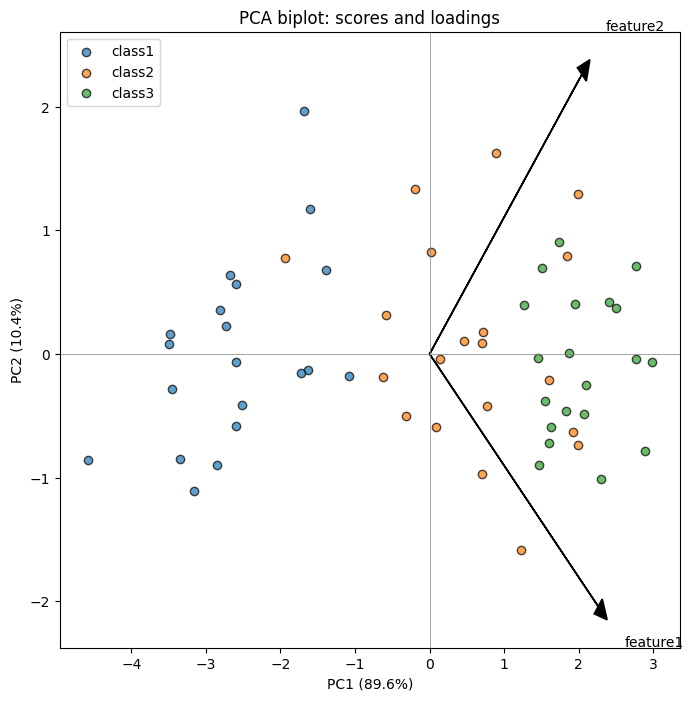

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

colors = ['r', 'g', 'b']
labels = ['class1', 'class2', 'class3']
for c, label in zip(range(3), labels):
    ax.scatter(X_pca[y == c, i], X_pca[y == c, j],
               label=label, alpha=0.7, edgecolors='k')

ax.set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
ax.set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]:.1%})')
ax.legend()
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)

feature_names = ['feature1', 'feature2']
loadings = pca.components_
scale = np.max(np.abs(X_pca)) * 0.7

for k in range(len(feature_names)):
    x_arrow = loadings[i, k] * scale
    y_arrow = loadings[j, k] * scale
    ax.arrow(0, 0, x_arrow, y_arrow,
             head_width=0.05*scale, head_length=0.05*scale,
             linewidth=1.2, color='black', length_includes_head=True)
    ax.text(x_arrow * 1.1, y_arrow * 1.1, feature_names[k],
            fontsize=10, color='black')

ax.set_title('PCA biplot: scores and loadings')
plt.show()

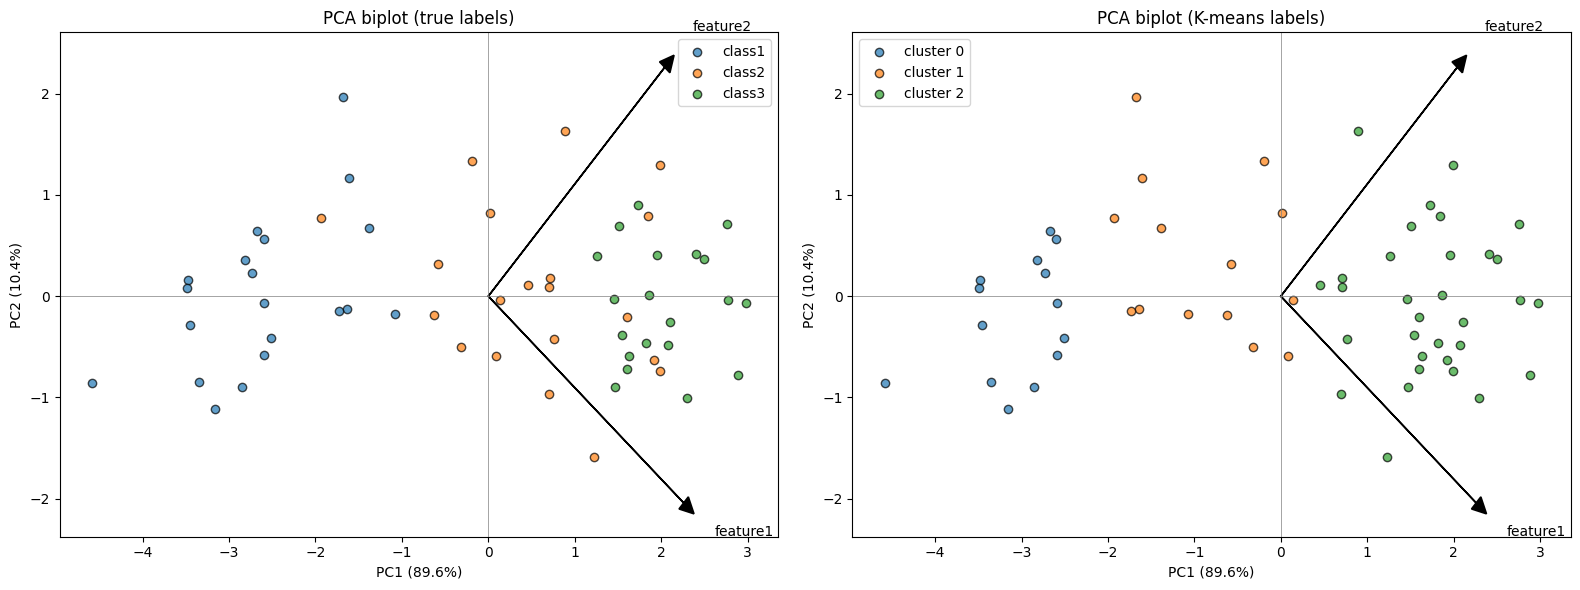

In [5]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

kmeans_pca = KMeans(n_clusters=3, random_state=2, n_init=20).fit(X_pca)
y_pca = kmeans_pca.labels_

mapping = {2: 0, 0: 1, 1: 2}
y_pca = np.array([mapping[c] for c in y_pca])

colors = ['r', 'g', 'b']
labels = ['class1', 'class2', 'class3']
feature_names = ['feature1', 'feature2']
loadings = pca.components_
scale = np.max(np.abs(X_pca)) * 0.7

fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 

i, j = 0, 1
for c, label in zip(range(3), labels):
    axes[0].scatter(X_pca[y == c, i], X_pca[y == c, j],
                    label=label, alpha=0.7, edgecolors='k')
axes[0].set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
axes[0].set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]:.1%})')
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_title('PCA biplot (true labels)')

for k in range(len(feature_names)):
    x_arrow = loadings[i, k] * scale
    y_arrow = loadings[j, k] * scale
    axes[0].arrow(0, 0, x_arrow, y_arrow,
                  head_width=0.05*scale, head_length=0.05*scale,
                  linewidth=1.2, color='black', length_includes_head=True)
    axes[0].text(x_arrow*1.1, y_arrow*1.1, feature_names[k],
                 fontsize=10, color='black')

for c, label in zip(range(3), labels):
    axes[1].scatter(X_pca[y_pca == c, i], X_pca[y_pca == c, j],
                    label=f'cluster {c}', alpha=0.7, edgecolors='k')
axes[1].set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
axes[1].set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]:.1%})')
axes[1].legend()
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_title('PCA biplot (K-means labels)')

for k in range(len(feature_names)):
    x_arrow = loadings[i, k] * scale
    y_arrow = loadings[j, k] * scale
    axes[1].arrow(0, 0, x_arrow, y_arrow,
                  head_width=0.05*scale, head_length=0.05*scale,
                  linewidth=1.2, color='black', length_includes_head=True)
    axes[1].text(x_arrow*1.1, y_arrow*1.1, feature_names[k],
                 fontsize=10, color='black')

plt.tight_layout()
plt.show()


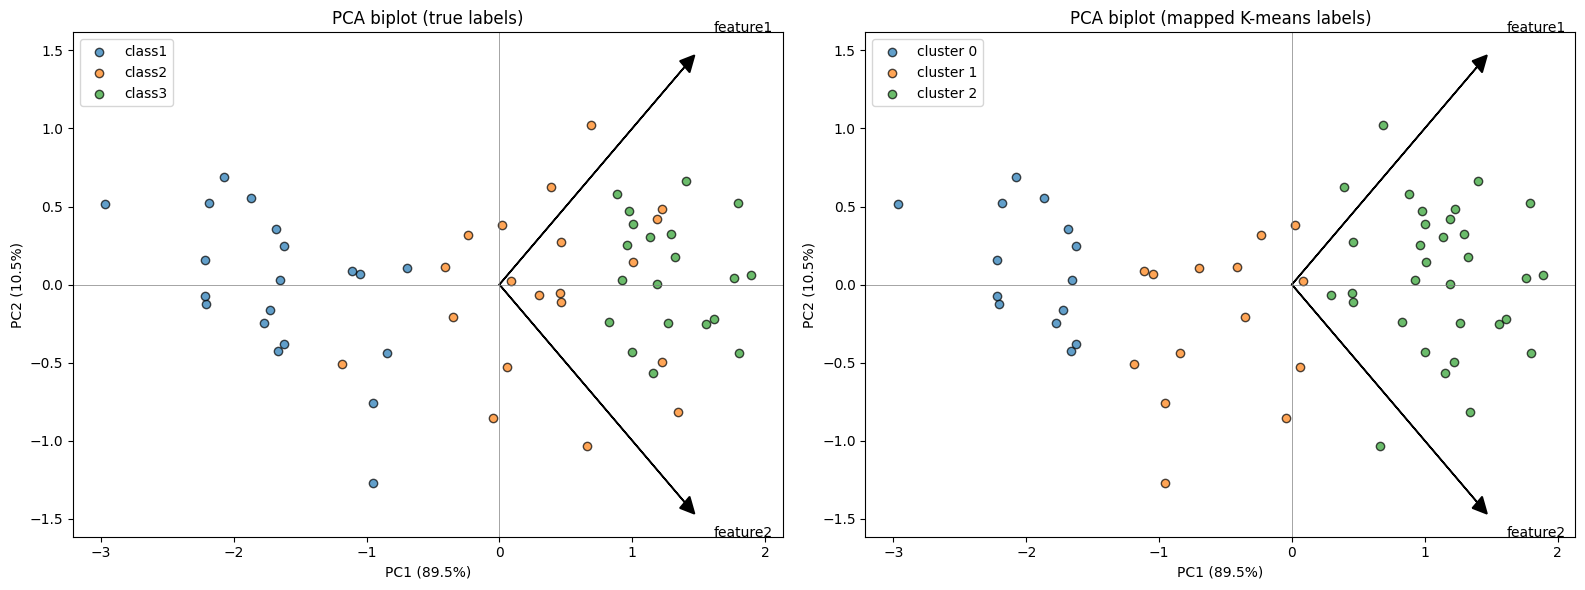

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=3, random_state=2, n_init=20).fit(X_pca)
y_pca = kmeans_pca.labels_


mapping_manual = {2:0, 1:2, 0:1}

y_pca_mapped = np.array([mapping_manual[label] for label in y_pca])

colors = ['r', 'g', 'b']
labels = ['class1', 'class2', 'class3']
feature_names = ['feature1', 'feature2']
loadings = pca.components_
scale = np.max(np.abs(X_pca)) * 0.7

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

i, j = 0, 1  # PC1, PC2

for c, label in zip(range(3), labels):
    axes[0].scatter(X_pca[y == c, i], X_pca[y == c, j],
                    label=label, alpha=0.7, edgecolors='k')
axes[0].set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
axes[0].set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]:.1%})')
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_title('PCA biplot (true labels)')

for k in range(len(feature_names)):
    x_arrow = loadings[i, k] * scale
    y_arrow = loadings[j, k] * scale
    axes[0].arrow(0, 0, x_arrow, y_arrow,
                  head_width=0.05*scale, head_length=0.05*scale,
                  linewidth=1.2, color='black', length_includes_head=True)
    axes[0].text(x_arrow*1.1, y_arrow*1.1, feature_names[k],
                 fontsize=10, color='black')


for c, label in zip(range(3), labels):
    axes[1].scatter(X_pca[y_pca_mapped == c, i], X_pca[y_pca_mapped == c, j],
                    label=f'cluster {c}', alpha=0.7, edgecolors='k')
axes[1].set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
axes[1].set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]:.1%})')
axes[1].legend()
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_title('PCA biplot (mapped K-means labels)')

for k in range(len(feature_names)):
    x_arrow = loadings[i, k] * scale
    y_arrow = loadings[j, k] * scale
    axes[1].arrow(0, 0, x_arrow, y_arrow,
                  head_width=0.05*scale, head_length=0.05*scale,
                  linewidth=1.2, color='black', length_includes_head=True)
    axes[1].text(x_arrow*1.1, y_arrow*1.1, feature_names[k],
                 fontsize=10, color='black')

plt.tight_layout()
plt.show()


#(c)
Perform K-means clustering of the observations with K =3.  How well do the clusters that you obtained in K-means clustering compare to the true class labels?
 Hint: You can use the pd.crosstab() function in Python to compare the true class labels to the class labels obtained by clustering. Be careful how you interpret the results: K-means clustering will arbitrarily number the clusters, so you cannot simply check whether the true class labels and clustering labels are the same.

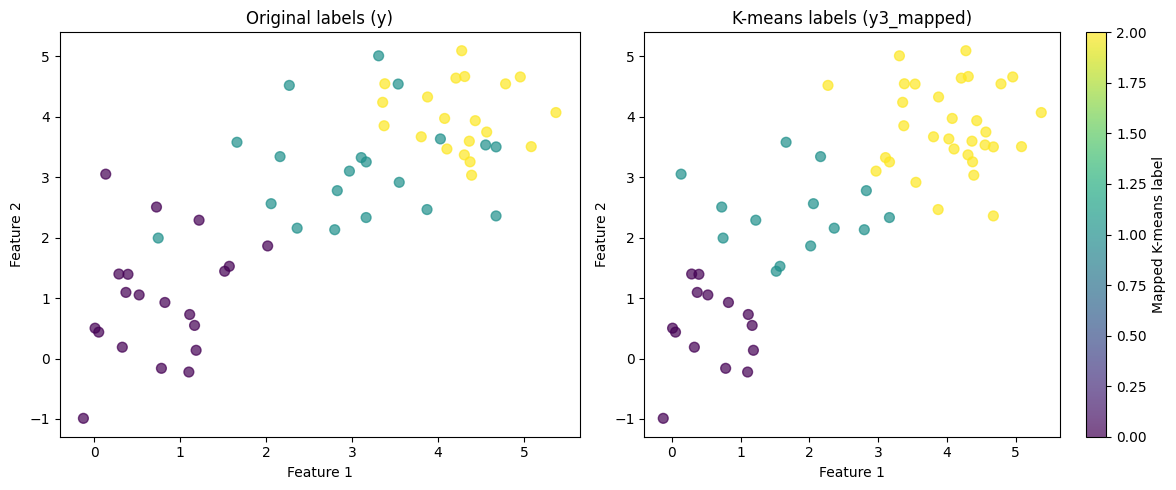

Accuracy: 0.7


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=2, n_init=20).fit(X_scaled)
y3 = kmeans.labels_

cm = confusion_matrix(y, y3)
row_ind, col_ind = linear_sum_assignment(-cm)
mapping = {old: new for old, new in zip(col_ind, row_ind)}
y3_mapped = np.array([mapping[label] for label in y3])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sc1 = axes[0].scatter(X[:,0], X[:,1], c=y, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title('Original labels (y)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

sc2 = axes[1].scatter(X[:,0], X[:,1], c=y3_mapped, cmap='viridis', s=50, alpha=0.7)
axes[1].set_title('K-means labels (y3_mapped)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_label('Mapped K-means label')

plt.tight_layout()
plt.show()

accuracy = accuracy_score(y, y3_mapped)
print("Accuracy:", accuracy)


#(d) 
Perform K-means clustering with K = 2. Describe your results

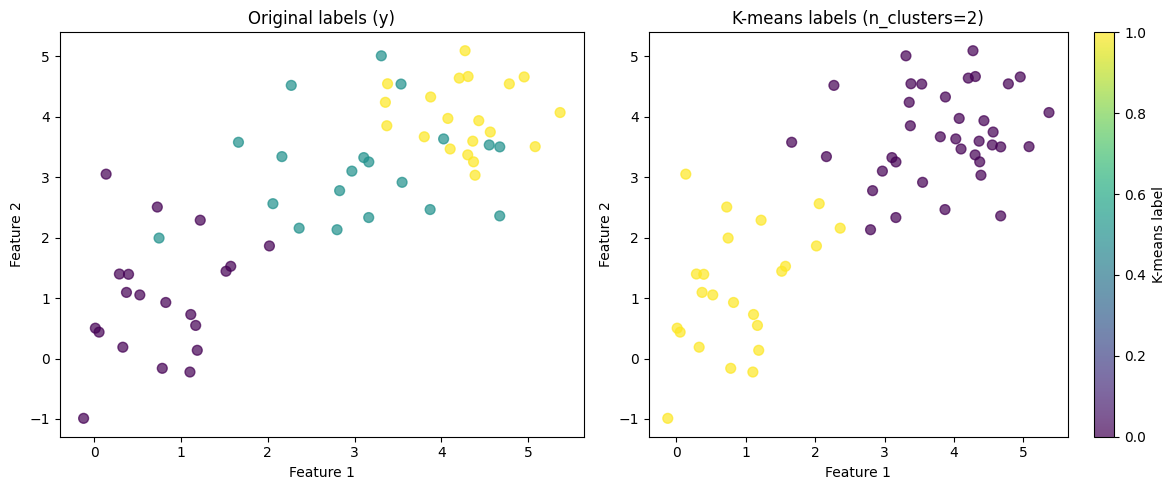

In [12]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans2 = KMeans(n_clusters=2, random_state=2, n_init=20).fit(X_scaled)
y2 = kmeans2.labels_

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

sc1 = axes[0].scatter(X[:,0], X[:,1], c=y, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title('Original labels (y)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

sc2 = axes[1].scatter(X[:,0], X[:,1], c=y2, cmap='viridis', s=50, alpha=0.7)
axes[1].set_title('K-means labels (n_clusters=2)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_label('K-means label')

plt.tight_layout()
plt.show()


#(e)
Now perform K-means clustering with K =4, and describe your results.

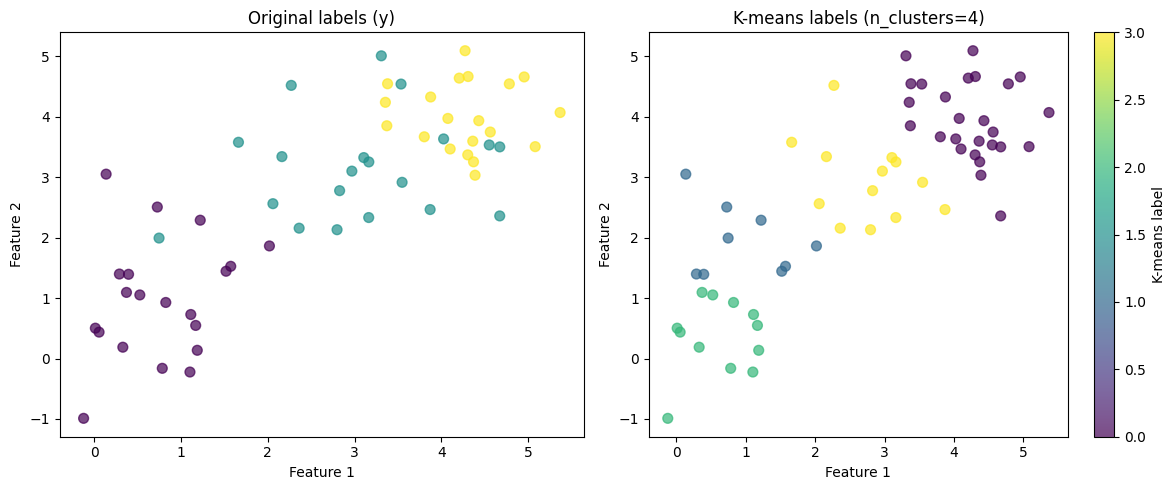

In [15]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans4 = KMeans(n_clusters=4, random_state=2, n_init=20).fit(X_scaled)
y4 = kmeans4.labels_

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

sc1 = axes[0].scatter(X[:,0], X[:,1], c=y, cmap='viridis', s=50, alpha=0.7)
axes[0].set_title('Original labels (y)')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

sc2 = axes[1].scatter(X[:,0], X[:,1], c=y4, cmap='viridis', s=50, alpha=0.7)
axes[1].set_title('K-means labels (n_clusters=4)')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_label('K-means label')

plt.tight_layout()
plt.show()


#(f) 
Now perform K-means clustering with K =3 on the first two principal component score vectors, rather than on the raw data. That is, perform K-means clustering on the 60 2 matrix of which the first column is the first principal component score vector, and the second column is the second principal component score vector. Comment on the results.

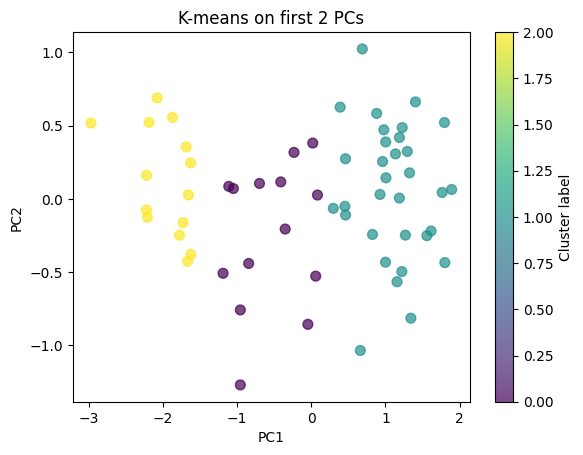

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

scaler = StandardScaler(with_std=True, with_mean=True)
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

from sklearn.cluster import KMeans
kmeans_pca = KMeans(n_clusters=3, random_state=2, n_init=20).fit(X_pca)
y_pca = kmeans_pca.labels_

import matplotlib.pyplot as plt
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_pca, cmap='viridis', s=50, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-means on first 2 PCs')
plt.colorbar(label='Cluster label')
plt.show()



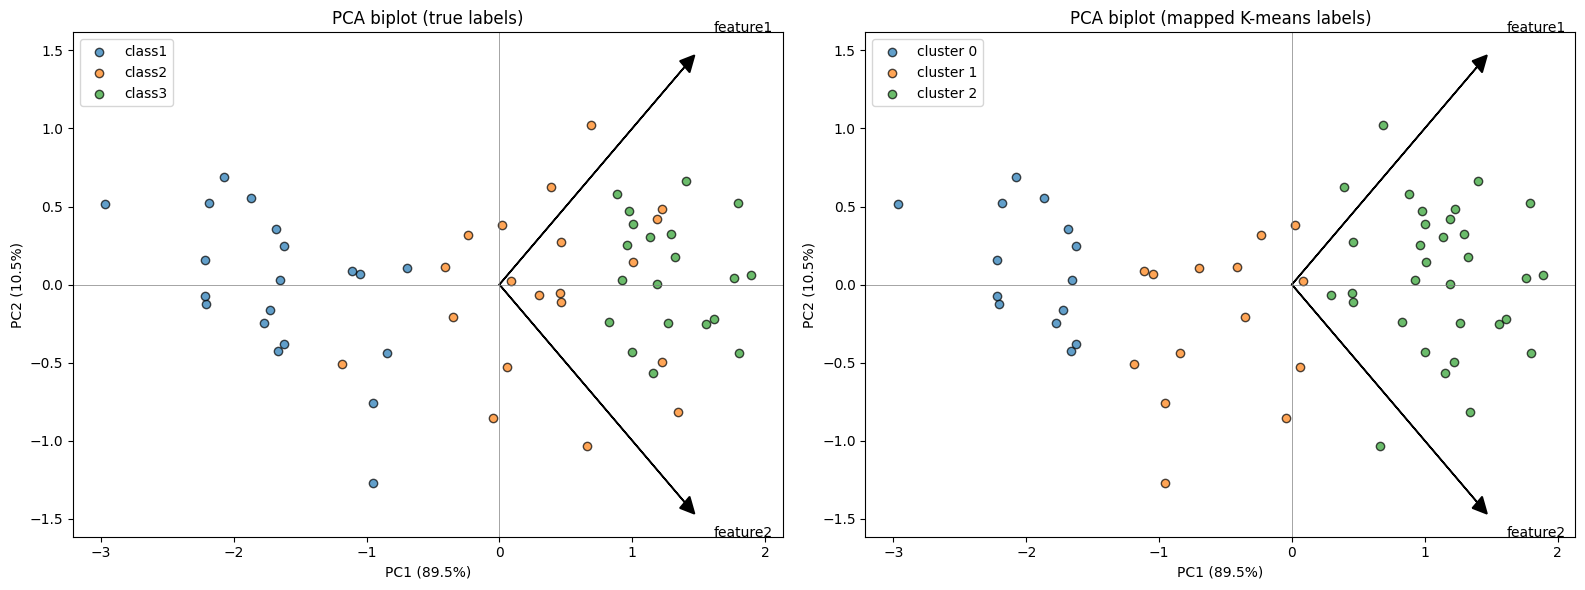

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=3, random_state=2, n_init=20).fit(X_pca)
y_pca = kmeans_pca.labels_


mapping_manual = {0:1, 1:2, 2:0}

y_pca_mapped = np.array([mapping_manual[label] for label in y_pca])


colors = ['r', 'g', 'b']
labels = ['class1', 'class2', 'class3']
feature_names = ['feature1', 'feature2']
loadings = pca.components_
scale = np.max(np.abs(X_pca)) * 0.7

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

i, j = 0, 1

for c, label in zip(range(3), labels):
    axes[0].scatter(X_pca[y == c, i], X_pca[y == c, j],
                    label=label, alpha=0.7, edgecolors='k')
axes[0].set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
axes[0].set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]:.1%})')
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_title('PCA biplot (true labels)')

for k in range(len(feature_names)):
    x_arrow = loadings[i, k] * scale
    y_arrow = loadings[j, k] * scale
    axes[0].arrow(0, 0, x_arrow, y_arrow,
                  head_width=0.05*scale, head_length=0.05*scale,
                  linewidth=1.2, color='black', length_includes_head=True)
    axes[0].text(x_arrow*1.1, y_arrow*1.1, feature_names[k],
                 fontsize=10, color='black')
    

for c, label in zip(range(3), labels):
    axes[1].scatter(X_pca[y_pca_mapped == c, i], X_pca[y_pca_mapped == c, j],
                    label=f'cluster {c}', alpha=0.7, edgecolors='k')
axes[1].set_xlabel(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})')
axes[1].set_ylabel(f'PC{j+1} ({pca.explained_variance_ratio_[j]:.1%})')
axes[1].legend()
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_title('PCA biplot (mapped K-means labels)')

for k in range(len(feature_names)):
    x_arrow = loadings[i, k] * scale
    y_arrow = loadings[j, k] * scale
    axes[1].arrow(0, 0, x_arrow, y_arrow,
                  head_width=0.05*scale, head_length=0.05*scale,
                  linewidth=1.2, color='black', length_includes_head=True)
    axes[1].text(x_arrow*1.1, y_arrow*1.1, feature_names[k],
                 fontsize=10, color='black')

plt.tight_layout()
plt.show()


#(g)
Using the StandardScaler() estimator, perform K-means clustering with K = 3 on the data after scaling each variable to have standard deviation one. How do these results compare to those obtained in (b)? Explain.

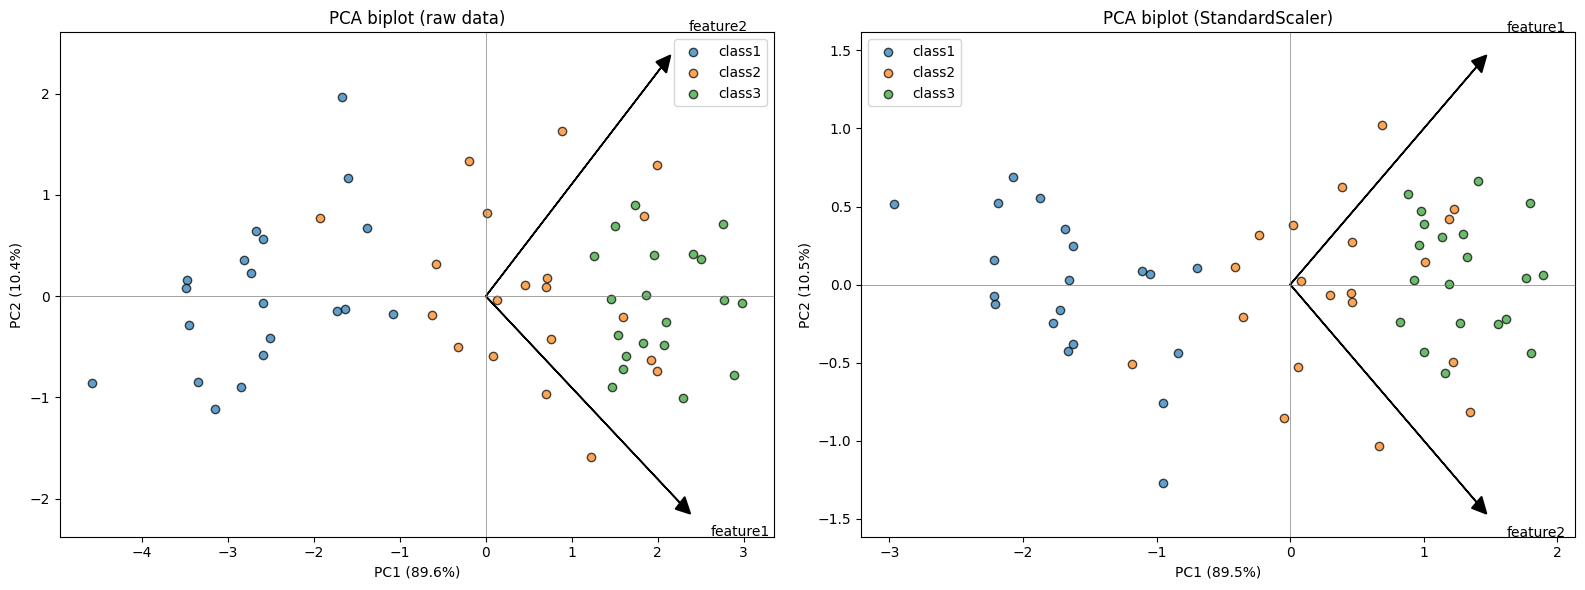

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

colors = ['r', 'g', 'b']
labels = ['class1', 'class2', 'class3']
feature_names = ['feature1', 'feature2']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
i, j = 0, 1

pca_raw = PCA(n_components=2)
X_pca_raw = pca_raw.fit_transform(X)

for c, label in zip(range(3), labels):
    axes[0].scatter(X_pca_raw[y == c, i], X_pca_raw[y == c, j],
                    label=label, alpha=0.7, edgecolors='k')

axes[0].set_xlabel(f'PC{i+1} ({pca_raw.explained_variance_ratio_[i]:.1%})')
axes[0].set_ylabel(f'PC{j+1} ({pca_raw.explained_variance_ratio_[j]:.1%})')
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].axvline(0, color='gray', linewidth=0.5)
axes[0].set_title('PCA biplot (raw data)')

scale_raw = np.max(np.abs(X_pca_raw)) * 0.7
loadings_raw = pca_raw.components_
for k in range(len(feature_names)):
    x_arrow = loadings_raw[i, k] * scale_raw
    y_arrow = loadings_raw[j, k] * scale_raw
    axes[0].arrow(0, 0, x_arrow, y_arrow,
                  head_width=0.05*scale_raw, head_length=0.05*scale_raw,
                  linewidth=1.2, color='black', length_includes_head=True)
    axes[0].text(x_arrow*1.1, y_arrow*1.1, feature_names[k],
                 fontsize=10, color='black')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA(n_components=2)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

for c, label in zip(range(3), labels):
    axes[1].scatter(X_pca_scaled[y == c, i], X_pca_scaled[y == c, j],
                    label=label, alpha=0.7, edgecolors='k')

axes[1].set_xlabel(f'PC{i+1} ({pca_scaled.explained_variance_ratio_[i]:.1%})')
axes[1].set_ylabel(f'PC{j+1} ({pca_scaled.explained_variance_ratio_[j]:.1%})')
axes[1].legend()
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].axvline(0, color='gray', linewidth=0.5)
axes[1].set_title('PCA biplot (StandardScaler)')

scale_scaled = np.max(np.abs(X_pca_scaled)) * 0.7
loadings_scaled = pca_scaled.components_
for k in range(len(feature_names)):
    x_arrow = loadings_scaled[i, k] * scale_scaled
    y_arrow = loadings_scaled[j, k] * scale_scaled
    axes[1].arrow(0, 0, x_arrow, y_arrow,
                  head_width=0.05*scale_scaled, head_length=0.05*scale_scaled,
                  linewidth=1.2, color='black', length_includes_head=True)
    axes[1].text(x_arrow*1.1, y_arrow*1.1, feature_names[k],
                 fontsize=10, color='black')

plt.tight_layout()
plt.show()
